In [57]:
import openeo
import json

connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [58]:
# Show possible connections and save them to .txt

connections_path = 'connection_list.txt'
connections = connection.list_collections()

with open(connections_path, 'w') as file:
    json.dump(connections, file, indent=2, sort_keys=True)

for item in connections:
    print(item.get("id"))

COPERNICUS_30
SENTINEL3_OLCI_L1B
SENTINEL3_SLSTR
SENTINEL_5P_L2
LANDSAT_BIMONTHLY_MOSAIC
COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON1
COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON2
COPERNICUS_PLANT_PHENOLOGY_INDEX
ESA_WORLDCOVER_10M_2020_V1
ESA_WORLDCOVER_10M_2021_V2
SENTINEL1_GLOBAL_MOSAICS
SENTINEL2_L2A
SENTINEL2_L1C
SENTINEL1_GRD
SENTINEL3_SYN_L2_SYN
SENTINEL3_SLSTR_L2_LST
SENTINEL3_OLCI_L2_LAND
SENTINEL3_OLCI_L2_WATER
SENTINEL3_SYN_L2_AOD


In [59]:
# Define rectangle to observe
bbox = {
    "west": -4.5,
    "east": -3.8,
    "south": 55.7,
    "north": 56.1
}

In [60]:
# Data request
datacube = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=bbox,
    temporal_extent=["2024-06-01", "2024-06-28"],
    bands=["NO2"]
)

print(datacube)
print(datacube.flat_graph())

DataCube(<PGNode 'load_collection' at 0x7f81d6c91310>)
{'loadcollection1': {'process_id': 'load_collection', 'arguments': {'bands': ['NO2'], 'id': 'SENTINEL_5P_L2', 'spatial_extent': {'west': -4.5, 'east': -3.8, 'south': 55.7, 'north': 56.1}, 'temporal_extent': ['2024-06-01', '2024-06-28']}, 'result': True}}


In [61]:
# Download defined data

datacube.download("glasgow_NO2.nc")

In [62]:
# Work with data pulled above
import xarray as xr

ds = xr.open_dataset("glasgow_NO2.nc")
print(ds)

<xarray.Dataset> Size: 17kB
Dimensions:  (t: 27, x: 13, y: 12)
Coordinates:
  * t        (t) datetime64[ns] 216B 2024-06-01 2024-06-02 ... 2024-06-27
  * x        (x) float64 104B -4.473 -4.418 -4.364 ... -3.927 -3.873 -3.818
  * y        (y) float64 96B 56.08 56.05 56.01 55.98 ... 55.8 55.77 55.74 55.7
Data variables:
    crs      |S1 1B ...
    NO2      (t, y, x) float32 17kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


In [63]:
# Bring in plots using matplotlib
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import pandas as pd

NO2_min = ds['NO2'].min().values
NO2_max = ds['NO2'].max().values
NO2_average = ds['NO2'].mean().values


NO2_min = np.array(NO2_min)
NO2_max = np.array(NO2_max)
NO2_average = np.array(NO2_average)

NO2_min = NO2_min.item()
NO2_max = NO2_max.item()
NO2_average = NO2_average.item()

# Round and print
print(f"Properties of dataset:")
print("==================================================================")
print(" ")
print(f"Range of NO_2 = {NO2_min:.3E} to {NO2_max:.3E} mol/m²")
print(f"Mean value: {NO2_average:.3E} mol/m²")
print(f"Date Range: {ds['t'].min().values} to {ds['t'].max().values}")
print(" ")
print("==================================================================")

Properties of dataset:
 
Range of NO_2 = -1.906E-05 to 7.095E-05 mol/m²
Mean value: 2.020E-05 mol/m²
Date Range: 2024-06-01T00:00:00.000000000 to 2024-06-27T00:00:00.000000000
 


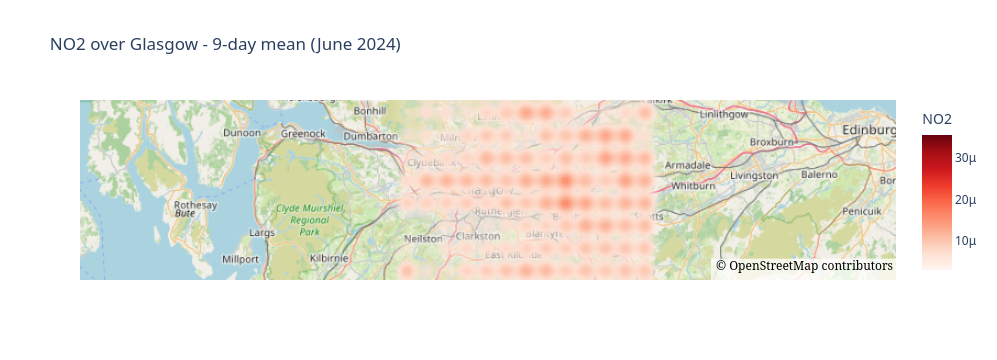

In [65]:
# Find best day
valid_counts = ds['NO2'].count(dim=['x', 'y'])
best_day_idx = valid_counts.argmax().values
best_day = ds.t.isel(t=best_day_idx).values

# Select +/- 4 days window, clamped to dataset bounds
t_start = max(0, best_day_idx - 4)
t_end = min(len(ds.t) - 1, best_day_idx + 4)

window = ds['NO2'].isel(t=slice(t_start, t_end + 1))

# Get the 9-day mean, mask negatives
no2_mean = window.mean(dim='t')
no2_clean = no2_mean.where(no2_mean > 0)

# Convert to dataframe for plotly
df = no2_clean.to_dataframe(name='NO2').reset_index().dropna()

fig = px.density_map(
    df, 
    lat='y', 
    lon='x', 
    z='NO2',
    radius=20,
    center={"lat": 55.86, "lon": -4.25},
    zoom=8,
    map_style="open-street-map",
    title="NO2 over Glasgow - 9-day mean (June 2024)",
    color_continuous_scale="Reds"
)

fig.show()